model dengan menggunakan multi stage jadi stage 1 untuk melihat tiap aspeknya stage 2 untuk melihat sentimen dari aspek tersebut tapi tiap mdel dan dia split datanya sama semua dekarang

dengan tf idf ngram 

tanpa smote karena pakai  multinominal nb



In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords


# ======================
# LOAD DATA
# ======================
df = pd.read_csv('label data keseluruhan perbaikan.csv', encoding='latin-1')
df.columns = df.columns.str.strip()

# ======================
# PREPROCESSING
# ======================

df_norm = pd.read_excel("normalisasi.xlsx")

norm_dict = dict(zip(
    df_norm['kata awal'],
    df_norm['kata perbaikan']
))


STOPWORDS_ID = {
    "yang","dan","di","ke","dari","untuk","dengan",
    "adalah","pada","ini","itu","atau","ada",
    "saya","kami","anda","dia","mereka",
    "akan","telah","lebih","semua","setiap","pun",
    "ya","yaa","nih","sih","siih","dong","deh","dehh",
    "aja","lah","lahh","kah","mah","eh","oh","ooh","ohh",
    "kok","tuh","doang","kan","begitu","gitu",
    "k","d","n","an","la",
    "hehe","hehehe","xixi","xixixi",
    "wkwk","wkwkwkw",
    "btw",
    "and","or",
    "sat", "pas",
    "tisp","weh","woi","bro","sis","cuk","anjir","anjay",
    "lagi","masih"
}

PROTECTED_WORDS = {
    "wifi", "ok",
    "gacoan", "wizzmie", "ramen","sushi","gelato"
}

NEGATION_WORDS = {
    "tidak", "bukan", "kurang", "belum", "jangan",
    "nggak", "ga", "gak", "gk", "tdk", "ngga", "kagak", "gx"
}

try:
    STOPWORDS_EN = set(stopwords.words("english"))
except:
    STOPWORDS_EN = set()

ALL_STOPS = STOPWORDS_ID | STOPWORDS_EN

factory = StemmerFactory()
stemmer = factory.create_stemmer()

SKIP_NEGATION_WORDS = {
    "terlalu",
    "cukup",
    "lumayan",
    "agak"
}

def handle_negation(words):
    result = []
    negating = False
    window = 0

    for w in words:
        if w in NEGATION_WORDS:
            negating = True
            window = 2
            result.append(w)
            continue

        if negating and window > 0:
            if w in SKIP_NEGATION_WORDS:
                result.append(w)
            else:
                result.append("NOT_" + w)
            window -= 1
        else:
            result.append(w)

        if window == 0:
            negating = False

    return result

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    for k, v in norm_dict.items():
        text = re.sub(rf'\b{re.escape(k)}\b', v, text)

    text = re.sub(r'[^a-z\s]', ' ', text)

    words = text.split()

    filtered_words = []
    for w in words:
        if w in ALL_STOPS and w not in NEGATION_WORDS:
            continue
        filtered_words.append(w)

    filtered_words = [w for w in filtered_words if len(w) > 2]

    words = handle_negation(filtered_words)

    clean_words = []
    for w in words:
        if w not in PROTECTED_WORDS and not w.startswith("NOT_"):
            w = stemmer.stem(w)
        clean_words.append(w)

    return " ".join(clean_words)


df['clean_text'] = df['text'].apply(preprocess_text)

# ======================
# ASPEK KEYWORDS
# ======================

ASPEK_KEYWORDS = {
    "makanan": [
        r"\b(rasa|enak|lezat|nikmat|hambar|gurih|manis|pedas|asam|asin|sambal|pahit)\b",
        r"\b(tasteless|delicious|tasty|yummy|flavou?r)\b",
        r"\b(mantap|mantul|sedap|nampol|nagih|ketagihan)\b",
        r"\b(bumbu|rempah|cita\s*rasa|bland)\b",
        r"\b(makanan\w*|menu\w*)\b.{0,20}\b(enak|lezat|mantap|sedap|juara|top)\b"
    ],
    "layanan": [
        r"\b(pelayan\w*|service|staff|staf|karyawan|waiter|waitress|mbak|mas)\b",
        r"\b(ramah|jutek|lambat|lama|cepat|cepet|responsif|respon)\b",
        r"\b(antri|antre|antrian|tunggu|nunggu|lelet)\b",
        r"\b(order\w*|pesan\w*)\b.{0,15}\b(lama|cepat|lambat)\b"
    ],
    "harga": [
        r"\b(harga|mahal|murah|affordable|worth|terjangkau|murmer|miring)\b",
        r"\b(price|budget|value|pricy|pricey|overprice|kemahalan)\b",
        r"\b(rupiah|ribu|rp\s?\d+|duit|uang|bayar|biaya|cost)\b",
        r"\b(worth\s*it|pas\s*di\s*kantong|ramah\s*kantong|kantong\s*(pelajar|mahasiswa))\b"
    ],
    "lingkungan": [
        r"\b(fasilitas\w*|tempat\w*|lokasi\w*|suasana\w*|atmosphere|ambience)\b",
        r"\b(bersih|kotor|jorok|nyaman|sempit|luas|adem|panas|dingin|pengap|gerah)\b",
        r"\b(parkir|toilet|ac|wifi|dekor\w*|interior|outdoor)\b",
        r"\b(meja|kursi|duduk|view|pemandangan)\b",
        r"\b(strategis|gampang\s*dijangkau)\b"
    ]
}

SENTIMENT_KEYWORDS = {
    "positif": [
        r"(?<!NOT_)\b(enak|lezat|mantap|mantul|sedap|nikmat|juara|top)\b",
        r"(?<!NOT_)\b(murah|terjangkau|worth|affordable|ramah\s*kantong)\b",
        r"(?<!NOT_)\b(ramah|cepat|responsif|baik|sopan)\b",
        r"(?<!NOT_)\b(nyaman|bersih|sejuk|adem|luas|enjoy|suka|love|recommended)\b",
        r"(?<!NOT_)\b(indah|estetik|aesthetic)\b"
    ],
    "negatif": [
        r"\bNOT_(enak|lezat|mantap|ramah|nyaman|bagus)\b",
        r"\b(tidak|tdk|nggak|gak|ga|ngga|kagak|bukan|jangan)\b\s*(enak|ramah|bagus)?",
        r"\b(kecewa|mengecewakan|buruk|jelek|parah|worst)\b",
        r"\b(rugi|menyesal|nyesel|kapok|zonk|scam)\b",
        r"\b(hambar|tasteless|bland|basi|busuk|benyek|keras|alot)\b",
        r"\b(lambat|lelet|lama\s*banget|kelamaan)\b",
        r"\b(mahal|mahal\s*banget|kemahalan|overprice|terlalu\s*mahal)\b",
        r"(?<!NOT_)\b(kotor|jorok|bau|pengap|gerah|sumpek|sempit(\s*banget)?)\b",
        r"\b(pelit|sedikit|dikit\s*banget|kurang\s*banyak)\b",
        r"\b(jutek|galak|sinis|cuek|tidak\s*ramah|gak\s*sopan)\b",
        r"\b(tidak\s*recommended|not\s*recommended|avoid|jangan\s*kesini)\b"
    ],
    "netral": [
        r"\b(biasa\s*aja|lumayan|so\s*so|standar|cukup|not\s*bad)\b",
        r"\b(ya\s*begitu|gitu\s*aja|oke\s*lah)\b"
    ]
}

def keyword_features(text):
    text = text.lower()
    fitur = []

    for asp, patterns in ASPEK_KEYWORDS.items():
        for p in patterns:
            if re.search(p, text):
                fitur.append(f"ASPEK_{asp}")

    for sent, patterns in SENTIMENT_KEYWORDS.items():
        for p in patterns:
            if re.search(p, text):
                fitur.append(f"SENT_{sent}")

    return " ".join(list(set(fitur)))

df['keyword_feat'] = df['clean_text'].apply(keyword_features)
df['final_text'] = df['clean_text'] + " " + df['keyword_feat']

# ======================
# SPLIT DATA
# ======================
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)

# ======================
# TF-IDF
# ======================
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=8000,
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)
X_train = tfidf.fit_transform(df_train['final_text'])
X_test  = tfidf.transform(df_test['final_text'])

# ======================
# INISIALISASI
# ======================
aspek_list = ['makanan', 'harga', 'lingkungan', 'layanan', 'umum']

model_aspek    = {}
model_kepuasan = {}   # ← ganti nama: model_sentimen → model_kepuasan
hasil_smote    = {}

# ======================
# PETA LABEL KEPUASAN
# Sesuai pelabelan CSV:
#   positif → 1 = Sangat Puas
#   negatif → 2 = Tidak Puas
#   netral  → 3 = Cukup Puas
#   0       = tidak membahas aspek (tidak masuk training)
# ======================
kepuasan_map = {
    'positif': 1,   # Sangat Puas
    'negatif': 2,   # Tidak Puas
    'netral' : 3,   # Cukup Puas
}


def build_multinomial_model(X_train, y_train):

    pos_count = int(y_train.sum()) if y_train.nunique() == 2 else len(y_train)
    pos_rate  = float(y_train.mean()) if len(y_train) > 0 else 0.5

    if pos_rate < 0.05 or pos_rate > 0.95:
        alpha = 3.0
    elif pos_rate < 0.10 or pos_rate > 0.90:
        alpha = 2.0
    else:
        alpha = 1.0

    base = MultinomialNB(alpha=alpha)

    if pos_count >= 6:
        cv = min(3, max(2, pos_count // 2))
        model = CalibratedClassifierCV(
            estimator=base,
            cv=cv,
            method="sigmoid"
        )
    else:
        model = base

    model.fit(X_train, y_train)
    return model


# ======================
# TRAINING LOOP
# ======================
for asp in aspek_list:

    print(f"Training: {asp.upper()}")

    # ----------------------------------
    # STAGE 1 — DETEKSI ASPEK (biner)
    # ----------------------------------
    y_train_b = df_train[f'numerik_{asp}'].apply(
        lambda x: 1 if x > 0 else 0
    )

    sm1 = SMOTE(random_state=42, k_neighbors=1)
    X_res_b, y_res_b = sm1.fit_resample(X_train, y_train_b)
    hasil_smote[asp] = y_res_b

    model_aspek[asp] = build_multinomial_model(X_res_b, y_res_b)

    # ----------------------------------
    # STAGE 2 — TINGKAT KEPUASAN
    # Hanya baris yang membahas aspek (numerik > 0)
    # ----------------------------------
    df_sub_train = df_train[df_train[f'numerik_{asp}'] > 0]

    if len(df_sub_train) > 5:

        X_sub_train = tfidf.transform(df_sub_train['final_text'])

        # Memetakan label teks → kode kepuasan (1 / 2 / 3)
        y_train_k = (
            df_sub_train[f'numerik_{asp}']
            .astype(int)
        )

        mask = y_train_k.notna()
        X_sub_train = X_sub_train[mask]
        y_train_k   = y_train_k[mask].astype(int)

        if len(np.unique(y_train_k)) > 1:

            sm2 = SMOTE(random_state=42, k_neighbors=1)
            X_res_k, y_res_k = sm2.fit_resample(X_sub_train, y_train_k)
            hasil_smote[asp]  = y_res_k

            model_kepuasan[asp] = build_multinomial_model(X_res_k, y_res_k)


# ======================
# FUNGSI PREDIKSI
# ======================

# Label output kepuasan
kepuasan_label = {
    1: "SANGAT PUAS",   # positif
    2: "TIDAK PUAS",    # negatif
    3: "CUKUP PUAS",    # netral
}


def predict_multilabel_kepuasan(text):

    clean = preprocess_text(text)
    kw    = keyword_features(clean)
    final = clean + " " + kw
    vec   = tfidf.transform([final])

    temp_results = []

    # ----------------------------------
    # PREDIKSI SEMUA ASPEK
    # ----------------------------------
    for asp in aspek_list:

        prob = model_aspek[asp].predict_proba(vec)[0][1]

        if prob > 0.70:

            if asp in model_kepuasan:

                # Kode kepuasan langsung: 1 / 2 / 3
                kode    = model_kepuasan[asp].predict(vec)[0]
                label   = kepuasan_label.get(kode, "CUKUP PUAS")

                temp_results.append((asp, kode, label))

    # ----------------------------------
    # FILTER ASPEK UMUM
    # ----------------------------------
    aspek_utama = {"makanan", "harga", "layanan", "lingkungan"}
    detected    = {a for a, _, _ in temp_results}

    if len(detected & aspek_utama) > 0:
        temp_results = [
            (a, k, l) for a, k, l in temp_results
            if a != "umum"
        ]

    # ----------------------------------
    # JIKA TIDAK ADA ASPEK TERDETEKSI
    # ----------------------------------
    if not temp_results:

        if "umum" in model_kepuasan:
            kode  = model_kepuasan["umum"].predict(vec)[0]
            label = kepuasan_label.get(kode, "CUKUP PUAS")
        else:
            kode, label = 0, "TIDAK DIBAHAS"

        temp_results.append(("umum", kode, label))

    # ----------------------------------
    # FORMAT OUTPUT
    # ----------------------------------
    results = [
        f"{a.upper()}: {l} (kode={k})"
        for a, k, l in temp_results
    ]

    return " | ".join(results)

Training: MAKANAN
Training: HARGA
Training: LINGKUNGAN
Training: LAYANAN
Training: UMUM


In [2]:
import os

# ======================================
# PATH FILE
# ======================================
# 1. Tentukan nama folder dan path file
output_dir = "output"
output_file = os.path.join(output_dir, "hasil nbm claude.txt")

# 2. TAMBAHKAN INI: Buat folder 'output' jika belum ada
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# ======================================
# TESTING
# ======================================

with open(output_file, "w", encoding="utf-8") as f:

    f.write("\n" + "="*60 + "\n")
    f.write("HASIL TESTING BANYAK\n")
    f.write("="*60 + "\n")

    test_kalimat = [
        "baru pertama kali kesini jadi belum bisa kasih penilaian",
        "Harga minumannya mahal banget",
        "Rasa makanannya mantap",
        "Toiletnya bersih",
        "Menu makanan variatif",
        "Rasa minumannya biasa aja",
        "Makanan masih hangat",
        "Minumannya segar",
        "Harga menu tidak masuk akal",
        "Harga menu cukup ramah kantong",
        "Harganya worth it",
        "Rasa sambalnya mantap",
        "Harga cocok untuk mahasiswa",
        "Harga murah meriah",
        "Lokasinya mudah dijangkau",
        "Makanan terlalu pedas",
        "Harga masih oke",
        "Interiornya bagus",
        "Tempatnya bersih kok"
    ]

    for i, kalimat in enumerate(test_kalimat, 1):
        # Pastikan fungsi predict_multilabel_kepuasan sudah didefinisikan di atas kode ini
        hasil = predict_multilabel_kepuasan(kalimat)

        f.write(f"\n[{i}]\n")
        f.write(f"Kalimat : {kalimat}\n")
        f.write(f"Prediksi: {hasil}\n")
        f.write("-"*60 + "\n")

print("✅ Hasil sudah disimpan ke file!")
print("📁 Lokasi file:")
print(os.path.abspath(output_file))

✅ Hasil sudah disimpan ke file!
📁 Lokasi file:
d:\jurnal sentimen fiks\model analisis\pemodelan_baru\Tunning\nbm\dataset_70.30\output\hasil nbm claude.txt


Evaluasi Accuracy, Precision, Recall, dan F1-Score ke TXT

In [4]:
# ======================
# EVALUASI STAGE 1 — DETEKSI ASPEK
# ======================
from sklearn.metrics import accuracy_score

print("=" * 45)
print("EVALUASI STAGE 1 — DETEKSI ASPEK")
print("=" * 45)

akurasi_stage1 = {}

for asp in aspek_list:

    y_test_b = df_test[f'numerik_{asp}'].apply(
        lambda x: 1 if x > 0 else 0
    )

    X_test_vec = tfidf.transform(df_test['final_text'])
    y_pred_b   = model_aspek[asp].predict(X_test_vec)

    acc = accuracy_score(y_test_b, y_pred_b)
    akurasi_stage1[asp] = acc

    print(f"  {asp.upper():<12} : {acc:.4f} ({acc*100:.2f}%)")

rata_rata_s1 = np.mean(list(akurasi_stage1.values()))
print("-" * 45)
print(f"  {'RATA-RATA':<12} : {rata_rata_s1:.4f} ({rata_rata_s1*100:.2f}%)")
print("=" * 45)



EVALUASI STAGE 1 — DETEKSI ASPEK
  MAKANAN      : 0.8741 (87.41%)
  HARGA        : 0.9680 (96.80%)
  LINGKUNGAN   : 0.9360 (93.60%)
  LAYANAN      : 0.9254 (92.54%)
  UMUM         : 0.9274 (92.74%)
---------------------------------------------
  RATA-RATA    : 0.9262 (92.62%)


In [11]:
# ======================
# EVALUASI STAGE 2 — TINGKAT KEPUASAN
# ======================
print()
print("=" * 45)
print("EVALUASI STAGE 2 — TINGKAT KEPUASAN")
print("=" * 45)

akurasi_stage2 = {}

for asp in aspek_list:

    df_sub_test = df_test[df_test[f'numerik_{asp}'] > 0]

    if asp not in model_kepuasan:
        print(f"  {asp.upper():<12} : model tidak tersedia")
        continue

    if len(df_sub_test) == 0:
        print(f"  {asp.upper():<12} : tidak ada data test")
        continue

    X_sub_test = tfidf.transform(df_sub_test['final_text'])

    y_test_k = df_sub_test[f'numerik_{asp}'].astype(int)
    y_pred_k = model_kepuasan[asp].predict(X_sub_test)

    acc = accuracy_score(y_test_k, y_pred_k)
    akurasi_stage2[asp] = acc                          # ← simpan

    print(f"  {asp.upper():<12} : {acc:.4f} ({acc*100:.2f}%)")

# --- Rata-rata hanya dari aspek yang berhasil dievaluasi ---
if akurasi_stage2:
    rata_rata_s2 = np.mean(list(akurasi_stage2.values()))
    print("-" * 45)
    print(f"  {'RATA-RATA':<12} : {rata_rata_s2:.4f} ({rata_rata_s2*100:.2f}%)")

print("=" * 45)


EVALUASI STAGE 2 — TINGKAT KEPUASAN
  MAKANAN      : 0.8425 (84.25%)
  HARGA        : 0.9045 (90.45%)
  LINGKUNGAN   : 0.8619 (86.19%)
  LAYANAN      : 0.9285 (92.85%)
  UMUM         : 0.7818 (78.18%)
---------------------------------------------
  RATA-RATA    : 0.8638 (86.38%)


# confusion matrix Stage 1, Stage 2, dan Keseluruhan

Tambahkan code ini setelah proses training selesai.


EVALUASI STAGE 1 — DETEKSI ASPEK

[MAKANAN]
  Akurasi : 0.8741 (87.41%)
                   precision    recall  f1-score   support

Tidak Dibahas (0)       0.87      0.85      0.86       682
      Dibahas (1)       0.88      0.89      0.89       819

         accuracy                           0.87      1501
        macro avg       0.87      0.87      0.87      1501
     weighted avg       0.87      0.87      0.87      1501


[HARGA]
  Akurasi : 0.9680 (96.80%)
                   precision    recall  f1-score   support

Tidak Dibahas (0)       0.98      0.98      0.98      1323
      Dibahas (1)       0.85      0.88      0.87       178

         accuracy                           0.97      1501
        macro avg       0.92      0.93      0.92      1501
     weighted avg       0.97      0.97      0.97      1501


[LINGKUNGAN]
  Akurasi : 0.9360 (93.60%)
                   precision    recall  f1-score   support

Tidak Dibahas (0)       0.93      0.97      0.95       936
      Dibahas (1

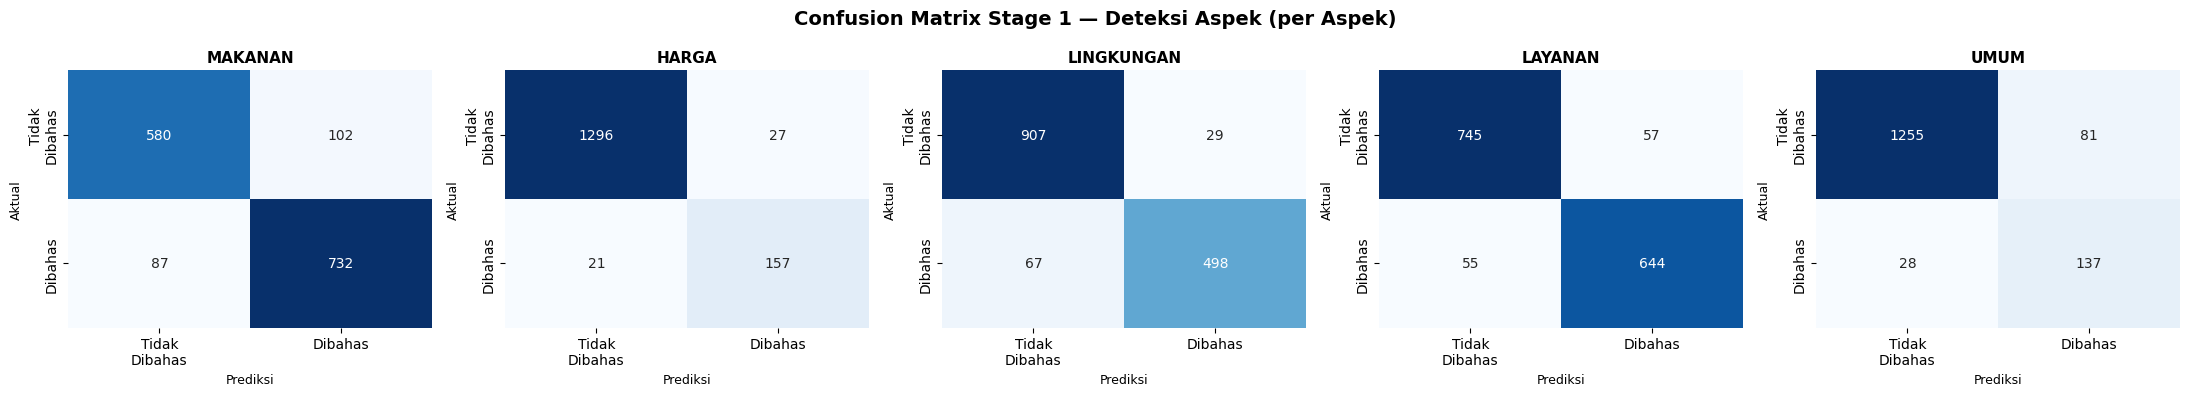

Confusion matrix Stage 1 disimpan: confusion_matrix_stage1.png


In [6]:
# ============================================================
# EVALUASI STAGE 1 — DETEKSI ASPEK (CONFUSION MATRIX 5x5)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

X_test_vec = tfidf.transform(df_test['final_text'])

# --- Kumpulkan prediksi semua aspek ---
y_true_all = []
y_pred_all = []

print("=" * 55)
print("EVALUASI STAGE 1 — DETEKSI ASPEK")
print("=" * 55)

akurasi_stage1 = {}

for asp in aspek_list:

    y_true_b = df_test[f'numerik_{asp}'].apply(
        lambda x: 1 if x > 0 else 0
    )
    y_pred_b = model_aspek[asp].predict(X_test_vec)

    acc = accuracy_score(y_true_b, y_pred_b)
    akurasi_stage1[asp] = acc

    print(f"\n[{asp.upper()}]")
    print(f"  Akurasi : {acc:.4f} ({acc*100:.2f}%)")
    print(classification_report(
        y_true_b, y_pred_b,
        target_names=["Tidak Dibahas (0)", "Dibahas (1)"],
        zero_division=0
    ))

    y_true_all.extend(y_true_b.tolist())
    y_pred_all.extend(y_pred_b.tolist())

rata_rata_s1 = np.mean(list(akurasi_stage1.values()))
print("=" * 55)
print(f"RATA-RATA AKURASI STAGE 1 : {rata_rata_s1:.4f} ({rata_rata_s1*100:.2f}%)")
print("=" * 55)


# --- Confusion Matrix 5x5 (per aspek, satu figure) ---
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Confusion Matrix Stage 1 — Deteksi Aspek (per Aspek)", fontsize=14, fontweight='bold')

for i, asp in enumerate(aspek_list):

    y_true_b = df_test[f'numerik_{asp}'].apply(
        lambda x: 1 if x > 0 else 0
    )
    y_pred_b = model_aspek[asp].predict(X_test_vec)

    cm = confusion_matrix(y_true_b, y_pred_b, labels=[0, 1])

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i],
        xticklabels=["Tidak\nDibahas", "Dibahas"],
        yticklabels=["Tidak\nDibahas", "Dibahas"],
        cbar=False
    )
    axes[i].set_title(asp.upper(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Prediksi", fontsize=9)
    axes[i].set_ylabel("Aktual", fontsize=9)

plt.tight_layout()
plt.savefig("confusion_matrix_stage1.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix Stage 1 disimpan: confusion_matrix_stage1.png")

In [13]:
# ============================================================
# EVALUASI STAGE 2 — TINGKAT KEPUASAN (CONFUSION MATRIX)
# ============================================================

kepuasan_label_map = {
    1: "Sangat Puas",
    2: "Tidak Puas",
    3: "Cukup Puas"
}

print("=" * 55)
print("EVALUASI STAGE 2 — TINGKAT KEPUASAN")
print("=" * 55)

stage2_data    = {}   # untuk plot
akurasi_stage2 = {}   # ← terpisah, khusus simpan akurasi

for asp in aspek_list:

    df_sub_test = df_test[df_test[f'numerik_{asp}'] > 0]

    if asp not in model_kepuasan:
        print(f"\n[{asp.upper()}] — model tidak tersedia")
        continue

    if len(df_sub_test) == 0:
        print(f"\n[{asp.upper()}] — tidak ada data test")
        continue

    X_sub_test = tfidf.transform(df_sub_test['final_text'])
    y_true_k   = df_sub_test[f'numerik_{asp}'].astype(int)
    y_pred_k   = model_kepuasan[asp].predict(X_sub_test)

    labels_present = sorted(set(y_true_k) | set(y_pred_k))
    target_names   = [kepuasan_label_map.get(l, str(l)) for l in labels_present]

    acc = accuracy_score(y_true_k, y_pred_k)
    akurasi_stage2[asp] = acc   # ← simpan akurasi saja

    print(f"\n[{asp.upper()}]")
    print(f"  Akurasi : {acc:.4f} ({acc*100:.2f}%)")
    print(classification_report(
        y_true_k, y_pred_k,
        labels=labels_present,
        target_names=target_names,
        zero_division=0
    ))

    stage2_data[asp] = {
        'y_true'        : y_true_k,
        'y_pred'        : y_pred_k,
        'labels_present': labels_present,
        'target_names'  : target_names
    }

# --- Rata-rata dari akurasi saja ---
if akurasi_stage2:
    rata_rata_s2 = np.mean(list(akurasi_stage2.values()))  # ← list of float
    print("-" * 55)
    print(f"RATA-RATA AKURASI STAGE 2 : {rata_rata_s2:.4f} ({rata_rata_s2*100:.2f}%)")

print("=" * 55)

EVALUASI STAGE 2 — TINGKAT KEPUASAN

[MAKANAN]
  Akurasi : 0.8425 (84.25%)
              precision    recall  f1-score   support

 Sangat Puas       0.94      0.89      0.91       674
  Tidak Puas       0.60      0.79      0.69        77
  Cukup Puas       0.37      0.44      0.40        68

    accuracy                           0.84       819
   macro avg       0.64      0.71      0.67       819
weighted avg       0.86      0.84      0.85       819


[HARGA]
  Akurasi : 0.9045 (90.45%)
              precision    recall  f1-score   support

 Sangat Puas       0.94      0.96      0.95       159
  Tidak Puas       0.64      1.00      0.78         7
  Cukup Puas       0.20      0.08      0.12        12

    accuracy                           0.90       178
   macro avg       0.59      0.68      0.62       178
weighted avg       0.88      0.90      0.89       178


[LINGKUNGAN]
  Akurasi : 0.8619 (86.19%)
              precision    recall  f1-score   support

 Sangat Puas       0.93      

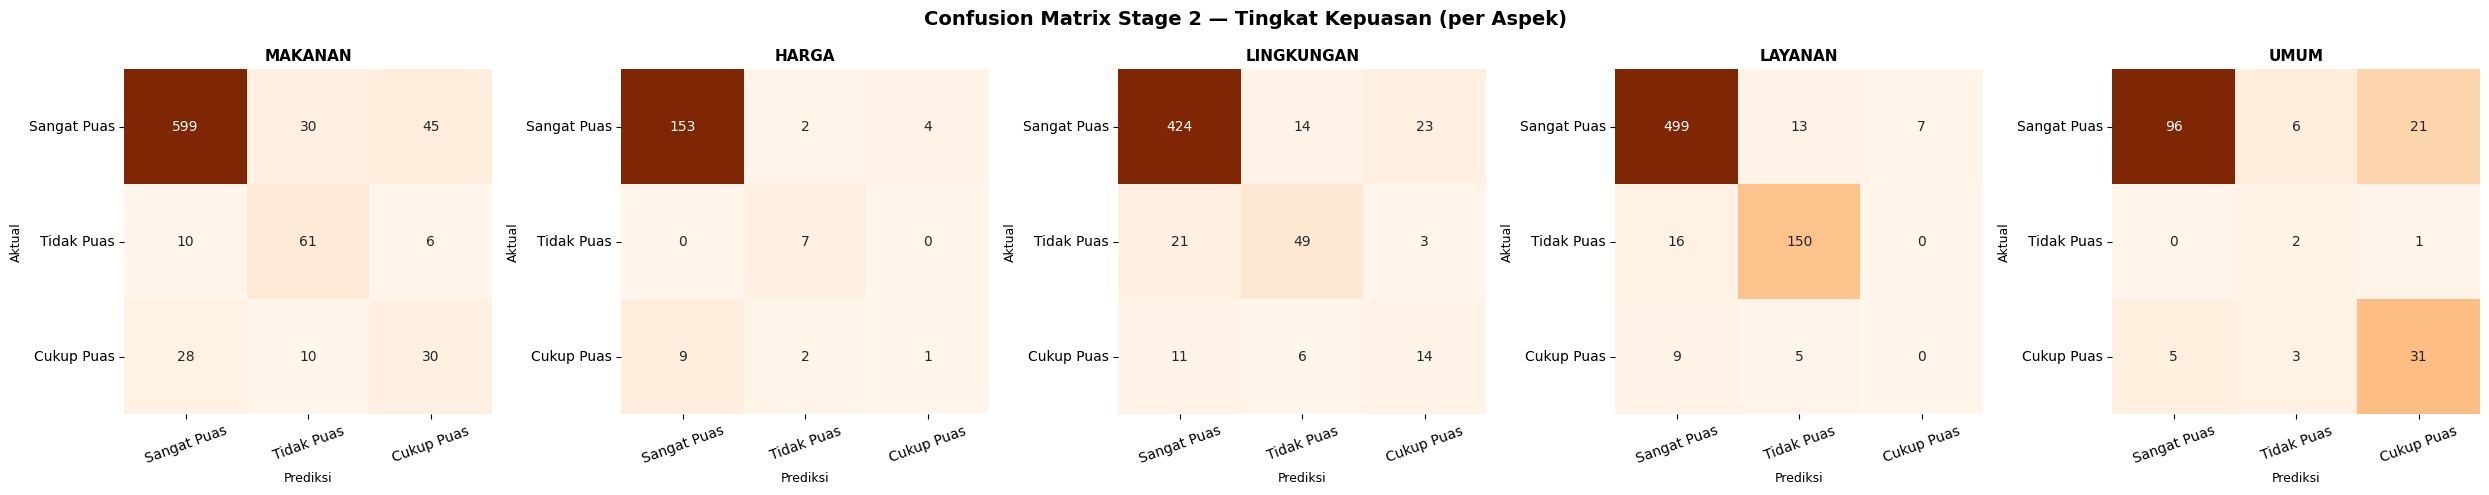

Confusion matrix Stage 2 disimpan: confusion_matrix_stage2.png


In [14]:
# --- Confusion Matrix Stage 2 (per aspek) ---
n_asp  = len(stage2_data)
fig, axes = plt.subplots(1, n_asp, figsize=(5 * n_asp, 5))
fig.suptitle("Confusion Matrix Stage 2 — Tingkat Kepuasan (per Aspek)", fontsize=14, fontweight='bold')

if n_asp == 1:
    axes = [axes]

for i, (asp, data) in enumerate(stage2_data.items()):

    cm = confusion_matrix(
        data['y_true'],
        data['y_pred'],
        labels=data['labels_present']
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Oranges',
        ax=axes[i],
        xticklabels=data['target_names'],
        yticklabels=data['target_names'],
        cbar=False
    )
    axes[i].set_title(asp.upper(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Prediksi", fontsize=9)
    axes[i].set_ylabel("Aktual", fontsize=9)
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig("confusion_matrix_stage2.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix Stage 2 disimpan: confusion_matrix_stage2.png")

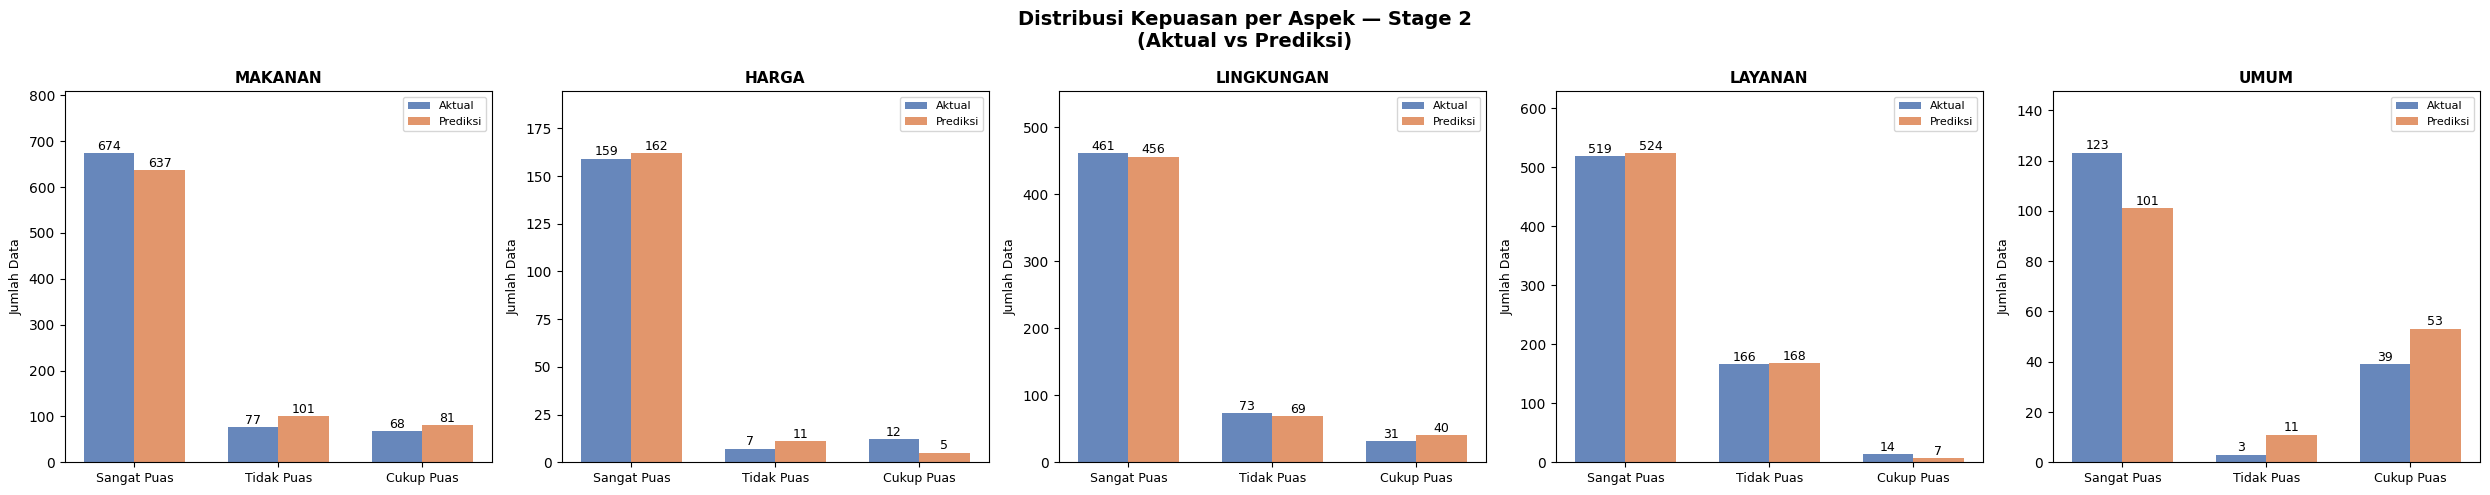

Distribusi kepuasan Stage 2 disimpan: distribusi_kepuasan_stage2.png


In [8]:
# ============================================================
# DISTRIBUSI KEPUASAN PER ASPEK — STAGE 2
# Jumlah aktual vs prediksi per tingkat kepuasan, tiap aspek
# ============================================================

fig, axes = plt.subplots(1, n_asp, figsize=(5 * n_asp, 5), sharey=False)
fig.suptitle("Distribusi Kepuasan per Aspek — Stage 2\n(Aktual vs Prediksi)", fontsize=14, fontweight='bold')

if n_asp == 1:
    axes = [axes]

warna_aktual  = "#4C72B0"
warna_prediksi = "#DD8452"

for i, (asp, data) in enumerate(stage2_data.items()):

    labels  = data['labels_present']
    names   = data['target_names']

    count_true = [np.sum(np.array(data['y_true']) == l) for l in labels]
    count_pred = [np.sum(np.array(data['y_pred']) == l) for l in labels]

    x      = np.arange(len(labels))
    width  = 0.35

    axes[i].bar(x - width/2, count_true, width, label='Aktual',   color=warna_aktual,   alpha=0.85)
    axes[i].bar(x + width/2, count_pred, width, label='Prediksi', color=warna_prediksi, alpha=0.85)

    # Angka di atas bar
    for j, (vt, vp) in enumerate(zip(count_true, count_pred)):
        axes[i].text(j - width/2, vt + 0.3, str(vt), ha='center', va='bottom', fontsize=9)
        axes[i].text(j + width/2, vp + 0.3, str(vp), ha='center', va='bottom', fontsize=9)

    axes[i].set_title(asp.upper(), fontsize=11, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(names, fontsize=9)
    axes[i].set_ylabel("Jumlah Data", fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].set_ylim(0, max(count_true + count_pred) * 1.2)

plt.tight_layout()
plt.savefig("distribusi_kepuasan_stage2.png", dpi=150, bbox_inches='tight')
plt.show()
print("Distribusi kepuasan Stage 2 disimpan: distribusi_kepuasan_stage2.png")